# Data Exploration - Phishing Dataset

Notebook for exploratory analysis: summary stats, null checks, feature distributions, correlation heatmap, and class balance.

Outputs are also exported to `../img`.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset path relative to notebooks/
DATA_PATH = "../data/dataset.csv"
IMG_DIR = "../img"

os.makedirs(IMG_DIR, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (116600, 26)


,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,24,rmit.edu.au,11,0,edu.au,6,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,26,latrobe.edu.au,14,0,edu.au,6,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,23,cqu.edu.au,10,0,edu.au,6,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,19,bond.edu.au,11,0,edu.au,6,0,13,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,22,csu.edu.au,10,0,edu.au,6,1,15,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


In [3]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 116600 entries, 0 to 116599
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   url           116600 non-null  str    
 1   url_len       116600 non-null  int64  
 2   dom           116600 non-null  str    
 3   dom_len       116600 non-null  int64  
 4   is_ip         116600 non-null  int64  
 5   tld           116586 non-null  str    
 6   tld_len       116600 non-null  int64  
 7   subdom_cnt    116600 non-null  int64  
 8   letter_cnt    116600 non-null  int64  
 9   digit_cnt     116600 non-null  int64  
 10  special_cnt   116600 non-null  int64  
 11  eq_cnt        116600 non-null  int64  
 12  qm_cnt        116600 non-null  int64  
 13  amp_cnt       116600 non-null  int64  
 14  dot_cnt       116600 non-null  int64  
 15  dash_cnt      116600 non-null  int64  
 16  under_cnt     116600 non-null  int64  
 17  letter_ratio  116600 non-null  float64
 18  digit_ratio   1

## Histograms

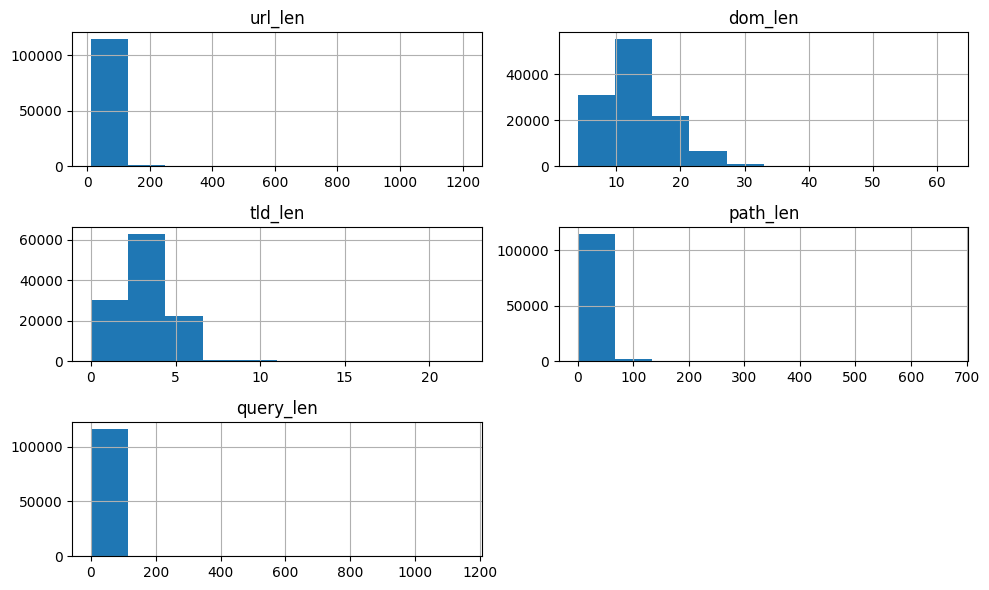

In [4]:
# Group 1: lengths
cols1 = ["url_len", "dom_len", "tld_len", "path_len", "query_len"]
df[cols1].hist(figsize=(10, 6))
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/hist_longitudes.png")
plt.show()
plt.close()

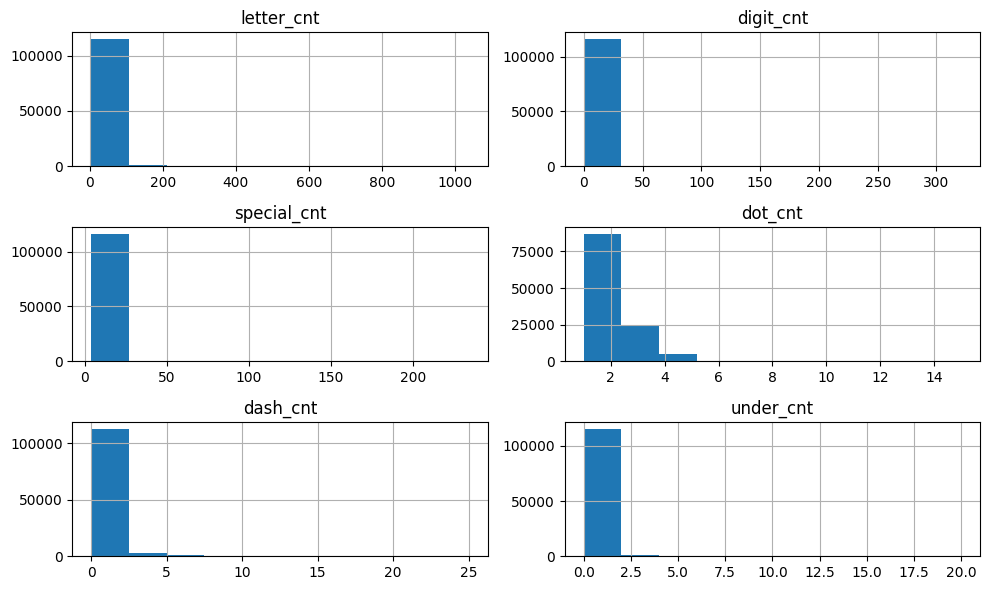

In [5]:
# Group 2: counts
cols2 = ["letter_cnt", "digit_cnt", "special_cnt", "dot_cnt", "dash_cnt", "under_cnt"]
df[cols2].hist(figsize=(10, 6))
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/hist_conteos.png")
plt.show()
plt.close()

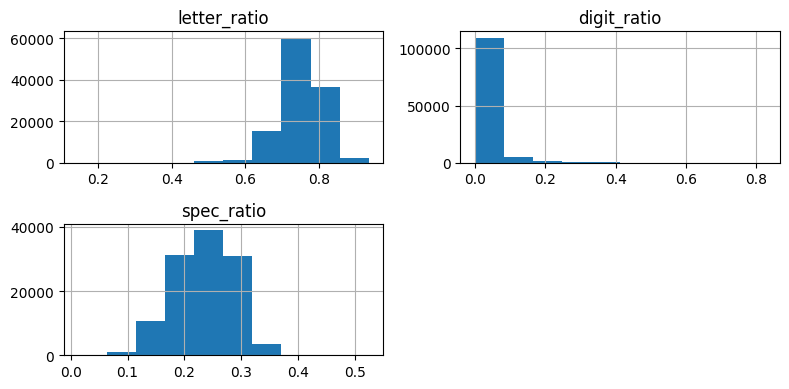

In [6]:
# Group 3: ratios
cols3 = ["letter_ratio", "digit_ratio", "spec_ratio"]
df[cols3].hist(figsize=(8, 4))
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/hist_ratios.png")
plt.show()
plt.close()

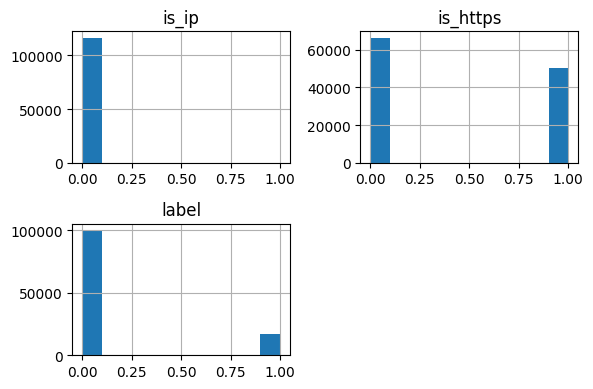

In [7]:
# Group 4: binaries + label
cols4 = ["is_ip", "is_https", "label"]
df[cols4].hist(figsize=(6, 4))
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/hist_binarios.png")
plt.show()
plt.close()

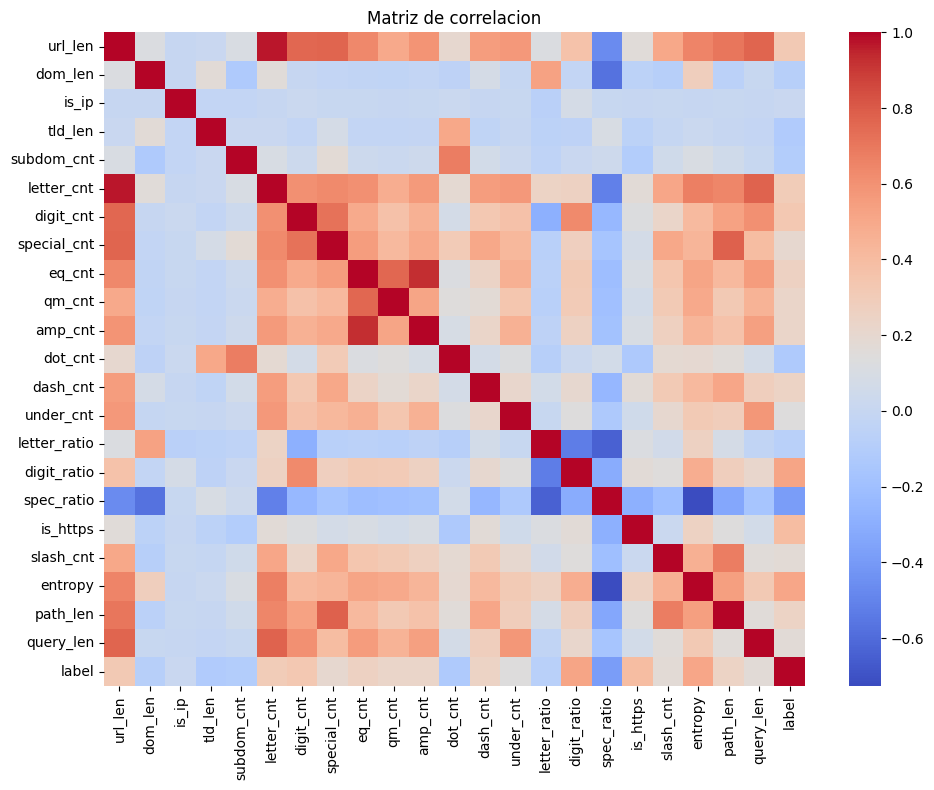

In [8]:
# Correlation heatmap
df_num = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(10, 8))
sns.heatmap(df_num.corr(), annot=False, cmap="coolwarm")
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/heatmap.png")
plt.show()
plt.close()

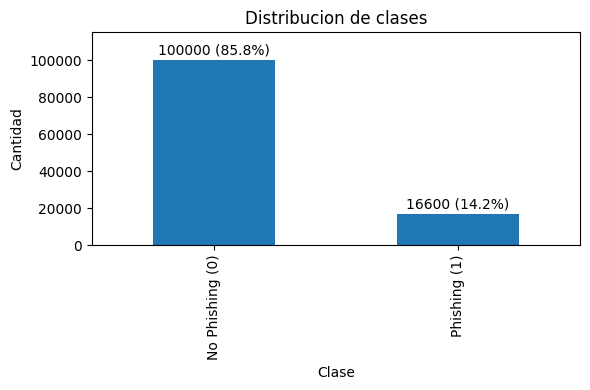

In [9]:
# Phishing count
conteo = df["label"].value_counts().sort_index()
total = conteo.sum()

# Bar graph for class distribution
plt.figure(figsize=(6, 4))
ax = conteo.plot(kind="bar")

plt.xticks([0, 1], ["No Phishing (0)", "Phishing (1)"])
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.title("Distribucion de clases")
y_max = conteo.max()
plt.ylim(0, y_max * 1.15)

for i, v in enumerate(conteo):
    porcentaje = (v / total) * 100
    ax.text(i, v + (y_max * 0.03), f"{v} ({porcentaje:.1f}%)", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/class_distribution.png")
plt.show()
plt.close()